# EfficientNet + ViT for Deepfake **Image** Detection (Class Project)

This notebook is a **class-project** version of the model pipeline.

It is adapted from the **Efficient ViT** idea in *Combining EfficientNet and Vision Transformers for Video Deepfake Detection*:
- **EfficientNet-B0** as the feature extractor
- flatten the spatial feature map into a token sequence
- add a **CLS token**
- pass the sequence through **Transformer encoder** blocks
- classify from the CLS output

For your class project, we use the **labeled training data only** and create our own:
- **train split**
- **validation split**
- **test split**

That gives you proper metrics such as:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

We do **not** use the competition's hidden-label test set for evaluation here.

## 1) Install packages

Run this first in Colab.

In [ ]:

!pip -q install kagglehub scikit-learn

## 2) Mount Google Drive

The notebook saves:
- best stage 1 checkpoint
- best final checkpoint
- final trained model
- metrics JSON
- plots

into your Google Drive.

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import os

SAVE_DIR = "/content/drive/MyDrive/deepfake_detection_project"
os.makedirs(SAVE_DIR, exist_ok=True)
print("Saving files to:", SAVE_DIR)

Saving files to: /content/drive/MyDrive/deepfake_class_project


## 3) Imports and seed setup


---





In [ ]:
import os
import re
import glob
import json
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision enabled")
except Exception as e:
    print("Mixed precision not enabled:", e)

try:
    tf.config.optimizer.set_jit(True)
    print("XLA JIT enabled")
except Exception as e:
    print("Could not enable XLA JIT:", e)

print("TensorFlow version:", tf.__version__)


Mixed precision enabled
XLA JIT enabled
TensorFlow version: 2.19.0


## 4) Download the Kaggle dataset

Dataset:
`alessandrasala79/ai-vs-human-generated-dataset`

In [ ]:

import kagglehub

DATASET_SLUG = "alessandrasala79/ai-vs-human-generated-dataset"
DATA_ROOT = kagglehub.dataset_download(DATASET_SLUG)
print("Dataset root:", DATA_ROOT)

Using Colab cache for faster access to the 'ai-vs-human-generated-dataset' dataset.
Dataset root: /kaggle/input/ai-vs-human-generated-dataset


## 5) Locate CSV files and inspect the dataset

In [ ]:

def find_first(patterns, root):
    for pattern in patterns:
        matches = glob.glob(os.path.join(root, "**", pattern), recursive=True)
        if matches:
            return matches[0]
    return None

train_csv = find_first(["train.csv"], DATA_ROOT)
test_csv = find_first(["test.csv"], DATA_ROOT)

print("train_csv:", train_csv)
print("test_csv:", test_csv)

train_csv: /kaggle/input/ai-vs-human-generated-dataset/train.csv
test_csv: /kaggle/input/ai-vs-human-generated-dataset/test.csv


In [ ]:

if train_csv is None:
    raise FileNotFoundError("Could not find train.csv inside the downloaded dataset.")

train_df = pd.read_csv(train_csv)
print("Train columns:", train_df.columns.tolist())
display(train_df.head())

if test_csv is not None:
    raw_test_df = pd.read_csv(test_csv)
    print("Competition test columns:", raw_test_df.columns.tolist())
    display(raw_test_df.head())
else:
    raw_test_df = None

Train columns: ['Unnamed: 0', 'file_name', 'label']


,Unnamed: 0,file_name,label
0,0,train_data/a6dcb93f596a43249135678dfcfc17ea.jpg,1
1,1,train_data/041be3153810433ab146bc97d5af505c.jpg,0
2,2,train_data/615df26ce9494e5db2f70e57ce7a3a4f.jpg,1
3,3,train_data/8542fe161d9147be8e835e50c0de39cd.jpg,0
4,4,train_data/5d81fa12bc3b4cea8c94a6700a477cf2.jpg,1


Competition test columns: ['id']


,id
0,test_data_v2/1a2d9fd3e21b4266aea1f66b30aed157.jpg
1,test_data_v2/ab5df8f441fe4fbf9dc9c6baae699dc7.jpg
2,test_data_v2/eb364dd2dfe34feda0e52466b7ce7956.jpg
3,test_data_v2/f76c2580e9644d85a741a42c6f6b39c0.jpg
4,test_data_v2/a16495c578b7494683805484ca27cf9f.jpg


## 6) Resolve image path and label columns

This notebook tries common column names automatically.

In [ ]:

def pick_column(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise ValueError(
            f"None of the candidate columns were found: {candidates}. "
            f"Available columns: {df.columns.tolist()}"
        )
    return None

PATH_COL = pick_column(train_df, ["file_name", "image_path", "path", "filename", "id"])
LABEL_COL = pick_column(train_df, ["label", "target", "class", "y"])

print("PATH_COL:", PATH_COL)
print("LABEL_COL:", LABEL_COL)

PATH_COL: file_name
LABEL_COL: label


In [ ]:

def build_candidate_paths(rel_path, root):
    rel_path = str(rel_path)
    candidates = []

    if os.path.isabs(rel_path):
        candidates.append(rel_path)

    candidates.append(os.path.join(root, rel_path))
    candidates.append(os.path.join(root, "train", rel_path))
    candidates.append(os.path.join(root, "images", rel_path))
    candidates.append(os.path.join(root, "data", rel_path))

    return candidates

def resolve_existing_path(rel_path, root):
    candidates = build_candidate_paths(rel_path, root)
    for p in candidates:
        if os.path.exists(p):
            return p

    matches = glob.glob(os.path.join(root, "**", os.path.basename(str(rel_path))), recursive=True)
    if matches:
        return matches[0]
    return None

train_df["abs_path"] = train_df[PATH_COL].apply(lambda p: resolve_existing_path(p, DATA_ROOT))
train_df = train_df[train_df["abs_path"].notna()].copy()

print("Rows with existing image paths:", len(train_df))
display(train_df[[PATH_COL, LABEL_COL, "abs_path"]].head())

Rows with existing image paths: 79950


,file_name,label,abs_path
0,train_data/a6dcb93f596a43249135678dfcfc17ea.jpg,1,/kaggle/input/ai-vs-human-generated-dataset/tr...
1,train_data/041be3153810433ab146bc97d5af505c.jpg,0,/kaggle/input/ai-vs-human-generated-dataset/tr...
2,train_data/615df26ce9494e5db2f70e57ce7a3a4f.jpg,1,/kaggle/input/ai-vs-human-generated-dataset/tr...
3,train_data/8542fe161d9147be8e835e50c0de39cd.jpg,0,/kaggle/input/ai-vs-human-generated-dataset/tr...
4,train_data/5d81fa12bc3b4cea8c94a6700a477cf2.jpg,1,/kaggle/input/ai-vs-human-generated-dataset/tr...


## 7) Optional grouped splitting

If the dataset provides a reliable pair/group column, use it to avoid leakage.

The code checks for common names such as:
- `group_id`
- `pair_id`
- `pair`
- `group`

If none exists, it falls back to a normal stratified split.

In [ ]:

GROUP_COL = None
for candidate in ["group_id", "pair_id", "pair", "group"]:
    if candidate in train_df.columns:
        GROUP_COL = candidate
        break

print("Detected GROUP_COL:", GROUP_COL)

Detected GROUP_COL: None


In [ ]:

print("Class distribution:")
display(train_df[LABEL_COL].value_counts(dropna=False))

Class distribution:


,count
label,
1,39975
0,39975


## 8) Create train / validation / test splits

For class projects, a simple and clean setup is:
- 70% train
- 15% validation
- 15% test

In [ ]:

def split_dataframe(df, label_col, group_col=None, val_size=0.15, test_size=0.15, seed=42):
    assert val_size + test_size < 1.0, "val_size + test_size must be less than 1"

    if group_col is not None:
        splitter1 = GroupShuffleSplit(
            n_splits=1,
            test_size=val_size + test_size,
            random_state=seed
        )
        train_idx, temp_idx = next(splitter1.split(df, y=df[label_col], groups=df[group_col]))
        train_part = df.iloc[train_idx].reset_index(drop=True)
        temp_part = df.iloc[temp_idx].reset_index(drop=True)

        relative_test_size = test_size / (val_size + test_size)

        splitter2 = GroupShuffleSplit(
            n_splits=1,
            test_size=relative_test_size,
            random_state=seed
        )
        val_idx, test_idx = next(splitter2.split(
            temp_part,
            y=temp_part[label_col],
            groups=temp_part[group_col]
        ))
        val_part = temp_part.iloc[val_idx].reset_index(drop=True)
        test_part = temp_part.iloc[test_idx].reset_index(drop=True)

    else:
        train_part, temp_part = train_test_split(
            df,
            test_size=val_size + test_size,
            stratify=df[label_col],
            random_state=seed
        )

        relative_test_size = test_size / (val_size + test_size)

        val_part, test_part = train_test_split(
            temp_part,
            test_size=relative_test_size,
            stratify=temp_part[label_col],
            random_state=seed
        )

        train_part = train_part.reset_index(drop=True)
        val_part = val_part.reset_index(drop=True)
        test_part = test_part.reset_index(drop=True)

    return train_part, val_part, test_part

tr_df, va_df, te_df = split_dataframe(
    train_df,
    label_col=LABEL_COL,
    group_col=GROUP_COL,
    val_size=0.15,
    test_size=0.15,
    seed=SEED
)

print("Train:", len(tr_df))
print("Validation:", len(va_df))
print("Test:", len(te_df))

Train: 55965
Validation: 11992
Test: 11993


## 10) Build TensorFlow datasets

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 64   # try 96 if GPU is still underused; reduce to 32 if OOM
AUTOTUNE = tf.data.AUTOTUNE
SHUFFLE_BUFFER = 10000
CACHE_TRAIN = False  # set True only if you have enough local disk space
CACHE_DIR = "/content/tf_cache_efficientvit"
os.makedirs(CACHE_DIR, exist_ok=True)


In [ ]:

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name="augmentation")

In [ ]:
def decode_and_resize(path, label):
    image_bytes = tf.io.read_file(path)
    path_lower = tf.strings.lower(path)

    is_jpeg = tf.strings.regex_full_match(path_lower, r".*\.(jpg|jpeg)")
    is_png = tf.strings.regex_full_match(path_lower, r".*\.png")

    image = tf.case([
        (is_jpeg, lambda: tf.io.decode_jpeg(image_bytes, channels=3)),
        (is_png, lambda: tf.io.decode_png(image_bytes, channels=3)),
    ], default=lambda: tf.io.decode_image(image_bytes, channels=3, expand_animations=False), exclusive=True)

    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE), antialias=True)
    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.float32)
    return image, label

def augment_batch(images, labels):
    images = data_augmentation(images, training=True)
    return images, labels

def configure_dataset(ds, training=False, cache_name=None):
    options = tf.data.Options()
    options.experimental_deterministic = False
    ds = ds.with_options(options)

    if training:
        ds = ds.shuffle(min(SHUFFLE_BUFFER, len(tr_df)), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE, deterministic=False)

    if cache_name is not None:
        ds = ds.cache(os.path.join(CACHE_DIR, cache_name))

    if training:
        ds = ds.batch(BATCH_SIZE, drop_remainder=True)
        ds = ds.map(augment_batch, num_parallel_calls=AUTOTUNE, deterministic=False)
    else:
        ds = ds.batch(BATCH_SIZE)

    ds = ds.prefetch(AUTOTUNE)
    return ds

def make_dataset(df, training=False, cache_name=None):
    ds = tf.data.Dataset.from_tensor_slices((
        df["abs_path"].values,
        df[LABEL_COL].values.astype("float32")
    ))
    return configure_dataset(ds, training=training, cache_name=cache_name)

train_cache_name = "train_cache" if CACHE_TRAIN else None
train_ds = make_dataset(tr_df, training=True, cache_name=train_cache_name)
val_ds = make_dataset(va_df, training=False, cache_name="val_cache")
test_ds = make_dataset(te_df, training=False, cache_name="test_cache")

print(f"Batch size: {BATCH_SIZE}")
print(f"Train cache enabled: {CACHE_TRAIN}")


Batch size: 64
Train cache enabled: False


## 11) Define the EfficientNet + ViT model

This follows the **image-level** version of the paper's Efficient ViT idea:
- EfficientNet-B0 backbone
- flatten spatial feature map into tokens
- add CLS token + positional embedding
- Transformer encoder
- binary classifier

In [ ]:

from tensorflow.keras import layers, models

In [ ]:

class ClassToken(layers.Layer):
    def build(self, input_shape):
        hidden_dim = input_shape[-1]
        self.cls = self.add_weight(
            name="cls_token",
            shape=(1, 1, hidden_dim),
            initializer=tf.keras.initializers.TruncatedNormal(stddev=0.02),
            trainable=True,
        )

    def call(self, x):
        batch_size = tf.shape(x)[0]
        cls_tokens = tf.broadcast_to(self.cls, [batch_size, 1, tf.shape(x)[-1]])
        return tf.concat([cls_tokens, x], axis=1)


class AddPositionEmbedding(layers.Layer):
    def build(self, input_shape):
        seq_len = input_shape[1]
        hidden_dim = input_shape[2]
        self.pos_emb = self.add_weight(
            name="pos_embedding",
            shape=(1, seq_len, hidden_dim),
            initializer=tf.keras.initializers.TruncatedNormal(stddev=0.02),
            trainable=True,
        )

    def call(self, x):
        return x + self.pos_emb


def mlp_block(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x


def transformer_encoder(x, projection_dim, num_heads, transformer_units, dropout_rate):
    x1 = layers.LayerNormalization(epsilon=1e-6)(x)
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=projection_dim,
        dropout=dropout_rate,
    )(x1, x1)
    x2 = layers.Add()([x, attention_output])

    x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
    x3 = mlp_block(x3, hidden_units=transformer_units, dropout_rate=dropout_rate)
    return layers.Add()([x2, x3])


def build_efficient_vit(
    input_shape=(224, 224, 3),
    projection_dim=256,
    transformer_layers=4,
    num_heads=8,
    transformer_units=(512, 256),
    mlp_head_units=(256, 128),
    dropout_rate=0.2,
):
    inputs = layers.Input(shape=input_shape)

    backbone = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_tensor=inputs,
        pooling=None
    )

    # Start with partial freezing for stable training in Colab
    for layer in backbone.layers[:-20]:
        layer.trainable = False
    for layer in backbone.layers[-20:]:
        layer.trainable = True

    x = backbone.output  # usually 7 x 7 x 1280 for 224x224 input
    x = layers.Reshape((-1, x.shape[-1]))(x)   # (B, H*W, C)
    x = layers.Dense(projection_dim)(x)        # linear projection

    x = ClassToken()(x)
    x = AddPositionEmbedding()(x)
    x = layers.Dropout(dropout_rate)(x)

    for _ in range(transformer_layers):
        x = transformer_encoder(
            x,
            projection_dim=projection_dim,
            num_heads=num_heads,
            transformer_units=transformer_units,
            dropout_rate=dropout_rate,
        )

    x = layers.LayerNormalization(epsilon=1e-6)(x)
    cls_output = x[:, 0]

    features = mlp_block(cls_output, hidden_units=mlp_head_units, dropout_rate=dropout_rate)
    outputs = layers.Dense(1, activation="sigmoid", dtype="float32", name="deepfake_prob")(features)

    model = models.Model(inputs=inputs, outputs=outputs, name="EfficientViT_Deepfake")
    return model

In [ ]:

model = build_efficient_vit(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    projection_dim=256,
    transformer_layers=4,
    num_heads=8,
    transformer_units=(512, 256),
    mlp_head_units=(256, 128),
    dropout_rate=0.2,
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "EfficientViT_Deepfake"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 13,959,844 (53.25 MB)

 Trainable params: 11,261,233 (42.96 MB)

 Non-trainable params: 2,698,611 (10.29 MB)

## 12) Compile the model

In [ ]:
def compile_model(model, lr):
    model.compile(
        optimizer=tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ],
        steps_per_execution=32,
        jit_compile=True,
    )

compile_model(model, lr=1e-3)


## 13) Train stage 1

This stage trains with most of the EfficientNet backbone still frozen.

In [ ]:

ckpt_stage1 = os.path.join(SAVE_DIR, "best_stage1.keras")

callbacks_stage1 = [
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_stage1,
        monitor="val_auc",
        mode="max",
        save_best_only=True
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=4,
        restore_best_weights=True
    ),
]

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3,
    callbacks=callbacks_stage1,
)

Epoch 1/8
874/874 ━━━━━━━━━━━━━━━━━━━━ 1402s 2s/step - accuracy: 0.8830 - auc: 0.9541 - loss: 0.2741 - precision: 0.8820 - recall: 0.8843 - val_accuracy: 0.9392 - val_auc: 0.9862 - val_loss: 0.1532 - val_precision: 0.9307 - val_recall: 0.9491
Epoch 2/8
874/874 ━━━━━━━━━━━━━━━━━━━━ 1105s 1s/step - accuracy: 0.9364 - auc: 0.9837 - loss: 0.1610 - precision: 0.9347 - recall: 0.9383 - val_accuracy: 0.9501 - val_auc: 0.9901 - val_loss: 0.1269 - val_precision: 0.9346 - val_recall: 0.9680
Epoch 3/8
874/874 ━━━━━━━━━━━━━━━━━━━━ 1106s 1s/step - accuracy: 0.9492 - auc: 0.9892 - loss: 0.1305 - precision: 0.9470 - recall: 0.9517 - val_accuracy: 0.9593 - val_auc: 0.9912 - val_loss: 0.1138 - val_precision: 0.9582 - val_recall: 0.9605
Epoch 4/8
874/874 ━━━━━━━━━━━━━━━━━━━━ 1131s 1s/step - accuracy: 0.9565 - auc: 0.9919 - loss: 0.1128 - precision: 0.9552 - recall: 0.9580 - val_accuracy: 0.9613 - val_auc: 0.9915 - val_loss: 0.1086 - val_precision: 0.9533 - val_recall: 0.9701
Epoch 5/8
874/874 ━━━━━━━━━━

## 14) Fine-tune stage 2

Now we unfreeze the whole backbone and continue training with a smaller learning rate.

In [ ]:

for layer in model.layers:
    if isinstance(layer, tf.keras.Model) and "efficientnet" in layer.name.lower():
        layer.trainable = True

compile_model(model, lr=1e-4)

ckpt_stage2 = os.path.join(SAVE_DIR, "best_stage2.keras")

callbacks_stage2 = [
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_stage2,
        monitor="val_auc",
        mode="max",
        save_best_only=True
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=5,
        restore_best_weights=True
    ),
]

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3,
    callbacks=callbacks_stage2,
)

Epoch 1/12
874/874 ━━━━━━━━━━━━━━━━━━━━ 1268s 1s/step - accuracy: 0.9725 - auc: 0.9966 - loss: 0.0703 - precision: 0.9708 - recall: 0.9743 - val_accuracy: 0.9723 - val_auc: 0.9944 - val_loss: 0.0850 - val_precision: 0.9692 - val_recall: 0.9757
Epoch 2/12
874/874 ━━━━━━━━━━━━━━━━━━━━ 1133s 1s/step - accuracy: 0.9742 - auc: 0.9967 - loss: 0.0676 - precision: 0.9740 - recall: 0.9744 - val_accuracy: 0.9723 - val_auc: 0.9942 - val_loss: 0.0849 - val_precision: 0.9689 - val_recall: 0.9760
Epoch 3/12
874/874 ━━━━━━━━━━━━━━━━━━━━ 1140s 1s/step - accuracy: 0.9740 - auc: 0.9968 - loss: 0.0675 - precision: 0.9734 - recall: 0.9746 - val_accuracy: 0.9720 - val_auc: 0.9942 - val_loss: 0.0862 - val_precision: 0.9693 - val_recall: 0.9748
Epoch 4/12
874/874 ━━━━━━━━━━━━━━━━━━━━ 1166s 1s/step - accuracy: 0.9736 - auc: 0.9969 - loss: 0.0670 - precision: 0.9721 - recall: 0.9752 - val_accuracy: 0.9724 - val_auc: 0.9944 - val_loss: 0.0849 - val_precision: 0.9704 - val_recall: 0.9745
Epoch 5/12
874/874 ━━━━━

## 15) Plot training curves

In [ ]:

def merge_history(*histories):
    merged = {}
    for h in histories:
        for k, v in h.history.items():
            merged.setdefault(k, []).extend(v)
    return merged

full_history = merge_history(history1, history2)

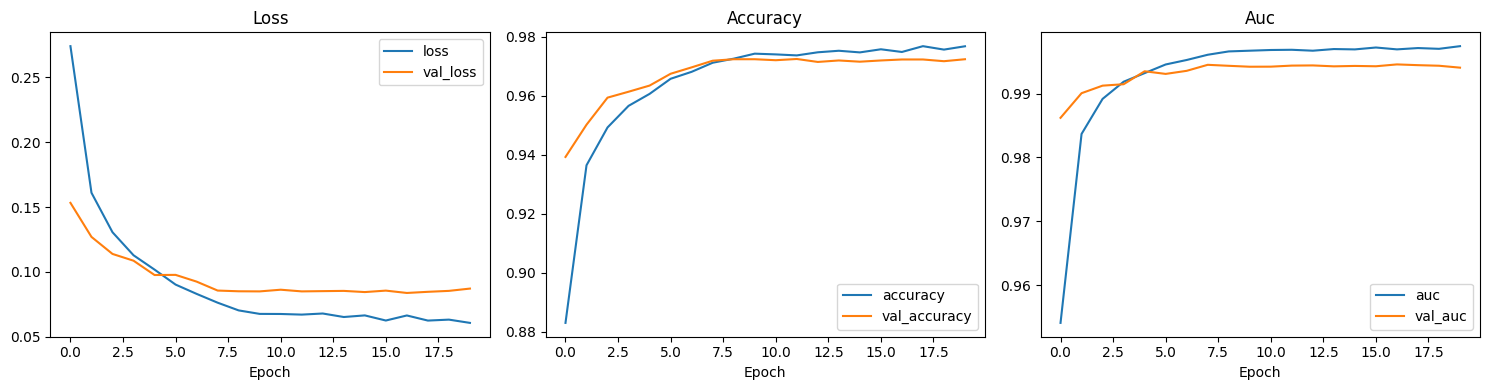

Saved: /content/drive/MyDrive/deepfake_class_project/training_curves.png


In [ ]:

def plot_training_curves(history_dict, save_dir):
    metric_pairs = [
        ("loss", "val_loss"),
        ("accuracy", "val_accuracy"),
        ("auc", "val_auc"),
    ]

    plt.figure(figsize=(15, 4))
    for i, (train_key, val_key) in enumerate(metric_pairs, 1):
        plt.subplot(1, 3, i)
        plt.plot(history_dict[train_key], label=train_key)
        plt.plot(history_dict[val_key], label=val_key)
        plt.title(train_key.replace("_", " ").title())
        plt.xlabel("Epoch")
        plt.legend()

    plt.tight_layout()
    plot_path = os.path.join(save_dir, "training_curves.png")
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", plot_path)

plot_training_curves(full_history, SAVE_DIR)

## 16) Tune the threshold on the validation set

Instead of forcing a threshold of `0.5`, we search for the threshold that gives the best validation **F1-score**.

In [ ]:

val_probs = model.predict(val_ds, verbose=1).ravel()
val_labels = va_df[LABEL_COL].values.astype(int)

best_thr = 0.5
best_f1 = 0.0

for thr in np.arange(0.10, 0.91, 0.01):
    preds = (val_probs >= thr).astype(int)
    score = f1_score(val_labels, preds)
    if score > best_f1:
        best_f1 = score
        best_thr = float(thr)

print("Best threshold:", best_thr)
print("Best validation F1:", best_f1)

188/188 ━━━━━━━━━━━━━━━━━━━━ 36s 191ms/step
Best threshold: 0.32999999999999985
Best validation F1: 0.9105731225296443


## 17) Evaluate on the held-out test split

This is the main class-project evaluation.

In [ ]:

test_probs = model.predict(test_ds, verbose=1).ravel()
test_labels = te_df[LABEL_COL].values.astype(int)
test_preds = (test_probs >= best_thr).astype(int)

metrics = {
    "threshold": best_thr,
    "accuracy": float(accuracy_score(test_labels, test_preds)),
    "precision": float(precision_score(test_labels, test_preds)),
    "recall": float(recall_score(test_labels, test_preds)),
    "f1": float(f1_score(test_labels, test_preds)),
    "roc_auc": float(roc_auc_score(test_labels, test_probs)),
}

print(json.dumps(metrics, indent=2))
print("\nClassification report:")
print(classification_report(test_labels, test_preds, digits=4))

In [ ]:

cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Real", "Fake"])
plt.yticks([0, 1], ["Real", "Fake"])
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
cm_path = os.path.join(SAVE_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", cm_path)

In [ ]:

fpr, tpr, _ = roc_curve(test_labels, test_probs)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"AUC = {metrics['roc_auc']:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()

roc_path = os.path.join(SAVE_DIR, "roc_curve.png")
plt.savefig(roc_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", roc_path)

## 18) Save the final model and metrics

In [ ]:

final_model_path = os.path.join(SAVE_DIR, "efficientvit_class_project.keras")
model.save(final_model_path)

metrics_path = os.path.join(SAVE_DIR, "test_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

split_info = {
    "train_size": int(len(tr_df)),
    "val_size": int(len(va_df)),
    "test_size": int(len(te_df)),
    "group_col_used": GROUP_COL
}
split_info_path = os.path.join(SAVE_DIR, "split_info.json")
with open(split_info_path, "w") as f:
    json.dump(split_info, f, indent=2)

print("Saved final model to:", final_model_path)
print("Saved metrics to:", metrics_path)
print("Saved split info to:", split_info_path)

Saved final model to: /content/drive/MyDrive/deepfake_class_project/efficientvit_class_project.keras
Saved metrics to: /content/drive/MyDrive/deepfake_class_project/test_metrics.json
Saved split info to: /content/drive/MyDrive/deepfake_class_project/split_info.json


## 19) Optional: inspect a few test predictions

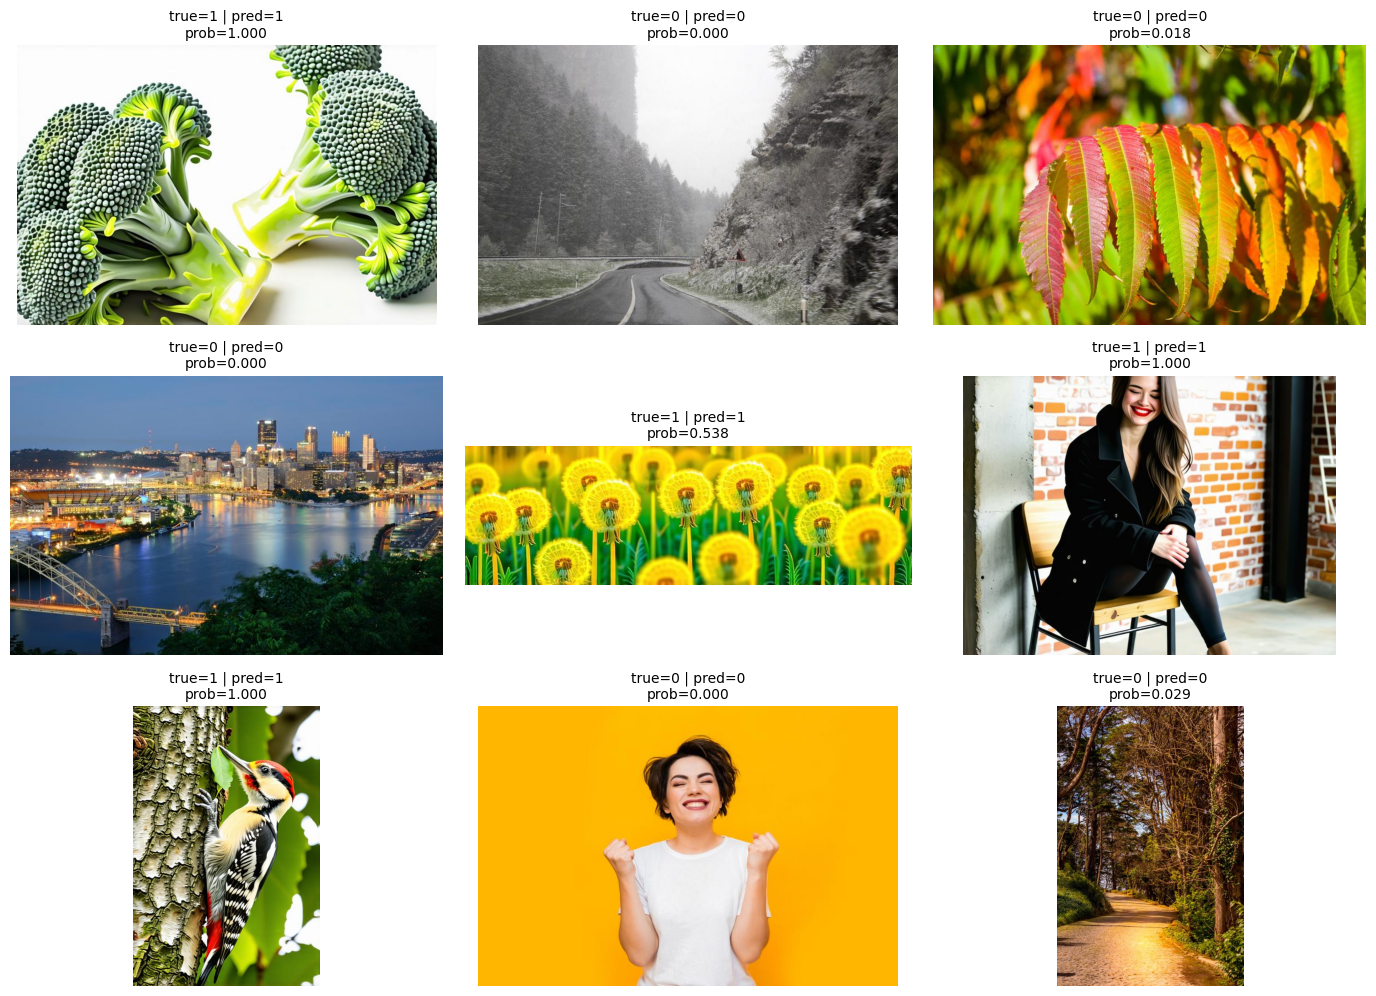

In [ ]:

preview_df = te_df.sample(n=min(9, len(te_df)), random_state=SEED).reset_index(drop=True)

def predict_one_image(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)
    image = tf.expand_dims(image, axis=0)
    prob = model.predict(image, verbose=0)[0][0]
    pred = int(prob >= best_thr)
    return prob, pred

plt.figure(figsize=(14, 10))
for i, row in preview_df.iterrows():
    img = plt.imread(row["abs_path"])
    prob, pred = predict_one_image(row["abs_path"])

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(
        f"true={int(row[LABEL_COL])} | pred={pred}\nprob={prob:.3f}",
        fontsize=10
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

## 20) What to report in your class project

A clean write-up can include:

1. **Dataset**
   - Kaggle AI vs Human Generated Images dataset
   - only labeled training data used for evaluation
   - created train / validation / test splits

2. **Model**
   - EfficientNet-B0 backbone
   - ViT-style Transformer encoder
   - CLS token classification head

3. **Training**
   - stage 1: partial freezing
   - stage 2: full fine-tuning
   - binary cross-entropy loss
   - SGD optimizer

4. **Evaluation**
   - tuned threshold on validation set
   - tested on held-out labeled test split
   - reported Accuracy, Precision, Recall, F1, ROC-AUC

5. **Limitation**
   - this is an image-level adaptation of a paper originally designed for video deepfake detection